In [ ]:
###################################################
###################################################
###################################################
###################################################

In [1]:

import os
import json
import re
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

# config ollama
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

MODEL_NAME = "mistral:7b"



In [ ]:
def is_bool_series(s: pd.Series) -> bool:
    # detecte si une collone pandas peut etre traite comme un booléen
    if pd.api.types.is_bool_dtype(s):
        return True
    if s.dtype == "object": #si c'est une colonne de type objet, on vérifie que les valeurs uniques sont dans un ensemble de valeurs booléennes possibles 
        vals = set(s.dropna().unique().tolist())
        return vals.issubset({True, False, "True", "False", "true", "false", 0, 1, "0", "1"})
    return False

def coerce_bool_value(v: Any) -> Optional[bool]: #convertit une valeur en booléen si possible, sinon retourne None
    if v is None:
        return None
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)) and v in (0, 1):
        return bool(int(v))
    if isinstance(v, str):
        t = v.strip().lower()
        if t in ("true", "vrai", "1", "yes", "y"):
            return True
        if t in ("false", "faux", "0", "no", "n"):
            return False
    return None

def safe_apply_filters(df: pd.DataFrame, filters: List[Dict[str, Any]]) -> pd.DataFrame: #applique des filtres en évitant les erreurs courantes
 
    if not filters:
        return df

    out = df.copy() #on travaille sur une copie du df
    for f in filters:
        col = f.get("column")
        val = f.get("value")
        op = f.get("op", "==")

        if col not in out.columns: #on verif que la colonne existe
            print(f"[filter] ignore: colonne inconnu {col}")
            continue

        s = out[col]

        # Bool : on force == True/False si possible
        if is_bool_series(s):
            b = coerce_bool_value(val)
            # si l'utilisateur n'a pas donné de valeur alors on filtre les True (ex: "IsConcealed" devient "IsConcealed == True")
            if b is None: 
                b = True
            out = out[s.astype(str).str.lower().isin([str(b).lower()])]
            continue

        # Si valeur fournie, on vérifie qu'elle existe (pour éviter df vide)
        if val is not None:
            # pour les colonnes de type objet/string, on vérifie que la valeur est dans les valeurs uniques (après conversion en str)
            if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
                uniques = set(s.dropna().astype(str).unique().tolist())
                if str(val) not in uniques:
                    print(f"[filter] ignore: la valeur '{val}' n'est pas dans les valeurs uniques de {col}")
                    continue

        # applique le filtre en fonction de l'opérateur
        if op == "==" or op is None: # par défaut on fait une égalité
            out = out[out[col] == val]
        elif op == "!=": 
            out = out[out[col] != val]
        elif op in (">", ">=", "<", "<="):
            sn = pd.to_numeric(out[col], errors="coerce")
            vn = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.isna(vn):
                print(f"[filter] ignore: valeur non numérique pour opé numérique: {val}")
                continue
            if op == ">": # attention aux xomparaisons numériques sur des colonnesqui sont pas numériques  à revoir
                out = out[sn > vn]
            elif op == ">=":
                out = out[sn >= vn]
            elif op == "<":
                out = out[sn < vn]
            elif op == "<=":
                out = out[sn <= vn]
        elif op == "contains":
            out = out[out[col].astype(str).str.contains(str(val), na=False)]
        elif op == "in" and isinstance(val, list): #appartenance à une liste de valeurs
            out = out[out[col].isin(val)]
        else:
            print(f"[filter] ignore: opération non supporté {op}")
            continue
        
        

    return out

In [3]:
def flatten_json(obj, parent="", sep="_"): #aplatit un json imbriqué end dictionnaire à plat
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k 
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items


def load_df(path: str, sample_rows: int = 5000): #charge les logs JSON en dataframe, ignore les lignes vides
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip() # nettoie les espaces dans les noms de colonnes
    return df


In [4]:
# On impose au modèle de retourner une structure d'intent très précise (JSON stucturé), qui sera ensuite utilisée pour construire la visualisation
INTENT_SYSTEM = """
You are a data visualization intent extractor.

Return ONLY valid JSON:

{
  "intent": "count" | "scatter" | "line" | "distribution",
  "group_by": string | null,
  "x": string | null,
  "y": string | null,
  "filter": [{"column": string, "value": any}] | []
}

Rules:
- Use ONLY column names provided in SCHEMA.
- If user asks for "nombre", "combien", "count", "répartition", use intent="count".
- Return JSON only.
"""

# Mistral va extraire l'intention de visualisation à partir du prompt utilisateur
# et du schéma de données, en respectant les règles définies dans INTENT_SYSTEM
# Le JSON retourné contiendra l'intent de visualisation, les colonnes à utiliser pour x et y,
# les éventuels group_by, et les filtres à appliquer.
def extract_intent(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    schema = list(df.columns) #on donne les colonnes au modéle

    msg = f"""
SCHEMA:
{schema}

USER_PROMPT:
{prompt}
"""

    response = client.chat.completions.create( #appel du LLM
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user", "content": msg},
        ],
        temperature=0.1
    )

    content = response.choices[0].message.content.strip()

    # nettoyage si besoin
    content = re.sub(r"^```(?:json)?", "", content).strip() # nettoie si le mdoèle met des balises de code
    content = re.sub(r"```$", "", content).strip()

    return json.loads(content)


In [5]:
def plot_from_intent(df: pd.DataFrame, intent: Dict[str, Any], prompt: str):
    print("\nDEBUG INTENTION:", intent)

    chart = (intent.get("chart") or "auto").lower() # par défaut on laisse le modèle choisir le type de graphique, mais on peut aussi lui demander explicitement (chart=line, chart=scatter, etc)
    group_by = intent.get("group_by") #ici on extrait les élements de l'intention : type de graphique, groupement, axes, filtres
    x = intent.get("x")
    y = intent.get("y")
    filters = intent.get("filter") or [] # Si filter est vide on met une liste vide pour éviter les problèmes plus tard

    # filtres d'abord, pour réduire le df au strict nécessaire (et éviter les problèmes de valeurs non existantes)
    df_f = safe_apply_filters(df, filters)

    # cas spécial : distribution avec colonne booléenne
    if group_by and x and x in df.columns: # on vérifie qu'il ya un group by, qu'il ya un x et que x existe dans les colonnes du df
        if df[x].dtype == bool: #on check si la coloonne x est booléenne
            df_bool = df[df[x] == True]  # on garde que les lignes où la colonne (x) est True
            counts = df_bool[group_by].value_counts().reset_index() # On compte combien d'occurences par catégorie
            counts.columns = [group_by, "count"] # on renomme les colonnes pour la suite 

            fig, ax = plt.subplots()
            ax.bar(counts[group_by].astype(str), counts["count"]) # on fait un bar plot de la distribution
            ax.set_title(prompt)
            return plt

    # Si tout est filtré malgré tout onr revient le sur df original
    if df_f.empty:
        print("[warn] Les filters ont produit un df vide, on repasse sur le df original.")
        df_f = df

    # 1) GROUP BY -> COUNT (avec ou sans filtre déjà appliqué)
    if group_by and group_by in df_f.columns:
        counts = df_f[group_by].value_counts(dropna=False).reset_index() 
        counts.columns = [group_by, "count"]

        fig, ax = plt.subplots()
        ax.bar(counts[group_by].astype(str), counts["count"])
        ax.set_xlabel(group_by)
        ax.set_ylabel("Count")
        ax.set_title(prompt)
        plt.xticks(rotation=45)
        plt.tight_layout()
        return plt

    # 2) COUNT SIMPLE 
    if intent.get("intent") == "count":
        # Si filtre bool déjà appliqué, df_f est déjà le sous-ensemble "avec"
        count_value = len(df_f)

        fig, ax = plt.subplots()
        ax.bar(["Count"], [count_value])
        ax.set_ylabel("Number of entities")
        ax.set_title(prompt)
        plt.tight_layout()
        return plt

    # 3) scatter
    if x and y and x in df_f.columns and y in df_f.columns:
        # convertir si possible
        xs = pd.to_numeric(df_f[x], errors="coerce")
        ys = pd.to_numeric(df_f[y], errors="coerce")
        ok = xs.notna() & ys.notna()
        fig, ax = plt.subplots()
        ax.scatter(xs[ok], ys[ok])
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(prompt)
        plt.tight_layout()
        return plt

    # 4) line (si chart=line ou si intent=time_series), à revoir pour éviter les confits avec le scatter 
    if (chart == "line" or intent.get("intent") in ("time_series", "trend")) and x and y and x in df_f.columns and y in df_f.columns:
        xs = df_f[x]
        ys = pd.to_numeric(df_f[y], errors="coerce")
        fig, ax = plt.subplots()
        ax.plot(xs, ys)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(prompt)
        plt.tight_layout()
        return plt

    raise ValueError("Impossible de déduire une stratégie de visualisation à partir de l'intention.")


In [6]:
import matplotlib.pyplot as plt


# run du pipeline, charge les données, extrait l'intention, génere le plot, sauvegarde et affiche le résultat
def run_llm_visualizer(
    file: str,
    prompt: str,
    out: str = "out3.png"
): 
    df = load_df(file)

    intent = extract_intent(prompt, df)
    print("\nINTENTION DETECTE:\n", intent)

    plt_obj = plot_from_intent(df, intent, prompt)

 
    plt_obj.savefig(out, bbox_inches="tight", dpi=300)

 
    plt_obj.show()


    plt_obj.close()

    print("\nGraph sauvegardé dans:", out)


In [7]:
df = load_df("data/lidata.log")
print(df.columns[:20])


Index(['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier',
       'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap',
       'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType',
       'Immobilized', 'IsConcealed', 'Marking', 'SimTime',
       'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi',
       'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta',
       'Spatial_FPB_VelocityVector_x'],
      dtype='object')


In [8]:
intent = extract_intent(
    "Bar chart du nombre d'entités par EntityType",
    df
)

print(intent)


{'intent': 'count', 'group_by': 'EntityType', 'x': None, 'y': 'count', 'filter': []}


In [7]:

df = load_df("data/lidata.log")
intent = extract_intent("Bar chart du nombre d'entités par EntityType", df)
print(intent)


{'intent': 'distribution', 'group_by': 'EntityType'}


In [9]:
print(df.columns.tolist())

['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier', 'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap', 'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType', 'Immobilized', 'IsConcealed', 'Marking', 'SimTime', 'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi', 'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta', 'Spatial_FPB_VelocityVector_x', 'Spatial_FPB_VelocityVector_y', 'Spatial_FPB_VelocityVector_z', 'Spatial_FPB_WorldLocation_x', 'Spatial_FPB_WorldLocation_y', 'Spatial_FPB_WorldLocation_z', 'Spatial_FPW_IsFrozen', 'Spatial_FPW_Orientation_phi', 'Spatial_FPW_Orientation_psi', 'Spatial_FPW_Orientation_theta', 'Spatial_FPW_VelocityVector_x', 'Spatial_FPW_VelocityVector_y', 'Spatial_FPW_VelocityVector_z', 'Spatial_FPW_WorldLocation_x', 'Spatial_FPW_WorldLocation_y', 'Spatial_FPW_WorldLocation_z', 'Spatial_FVB_IsFrozen', 'Spatial_FVB_Orientation_phi', 'Spatial_FVB_Orientation_psi', 'Spatial_FVB_Orientation_theta', 'Spatial_FVB

In [9]:
print(intent["group_by"])


NameError: name 'intent' is not defined


INTENTION DETECTE:
 {'intent': 'count', 'group_by': 'EntityType'}

DEBUG INTENTION: {'intent': 'count', 'group_by': 'EntityType'}


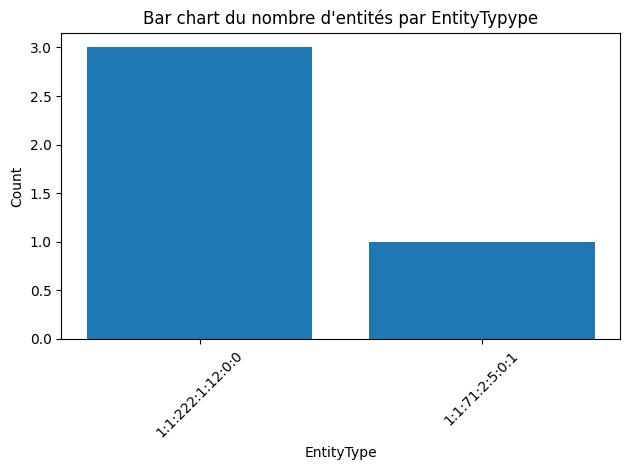


Graph sauvegardé dans: out5.png


In [22]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Bar chart du nombre d'entités par EntityTypype",
    out="out5.png"
)



INTENTION DETECTE:
 {'intent': 'distribution', 'group_by': 'ForceIdentifier'}

DEBUG INTENTION: {'intent': 'distribution', 'group_by': 'ForceIdentifier'}


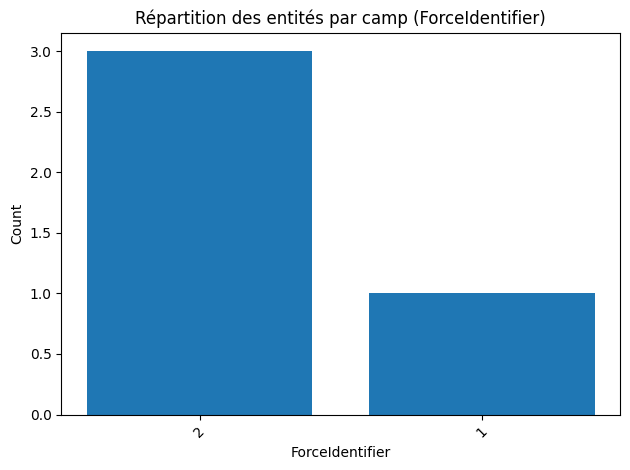


Graph sauvegardé dans: out6.png


In [10]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des entités par camp (ForceIdentifier)",
    out="out6.png"
    
)


INTENTION DETECTE:
 {'intent': 'count', 'group_by': None, 'x': None, 'y': 'EntityIdentifier', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False}]}

DEBUG INTENTION: {'intent': 'count', 'group_by': None, 'x': None, 'y': 'EntityIdentifier', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False}]}


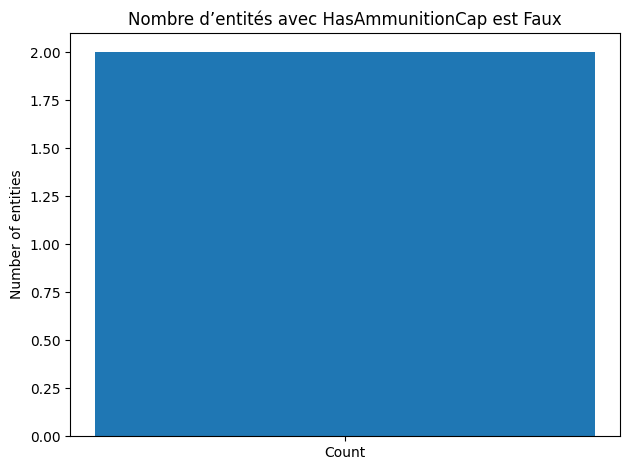


Graph sauvegardé dans: out.png


In [16]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Nombre d’entités avec HasAmmunitionCap est Faux",
    out="out.png"
)



INTENTION DETECTE:
 {'intent': 'distribution', 'group_by': 'EntityType', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': True}]}

DEBUG INTENTION: {'intent': 'distribution', 'group_by': 'EntityType', 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': True}]}


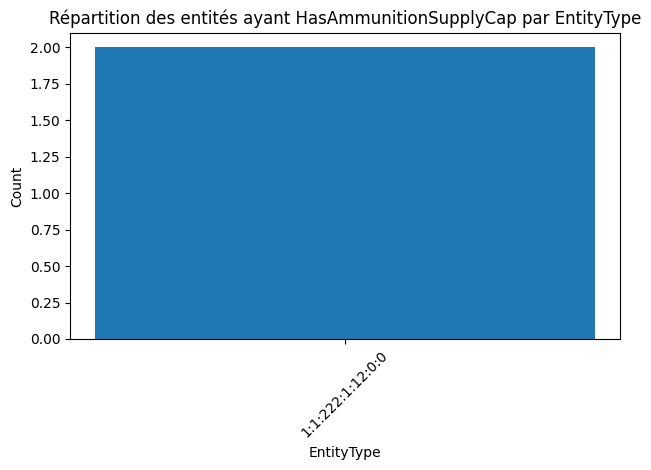


Graph sauvegardé dans: out.png


In [21]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des entités ayant HasAmmunitionSupplyCap par EntityType",
    out="out.png"
)



INTENT DETECTED:
 {'intent': 'distribution', 'group_by': 'ForceIdentifier'}

DEBUG INTENT: {'intent': 'distribution', 'group_by': 'ForceIdentifier'}


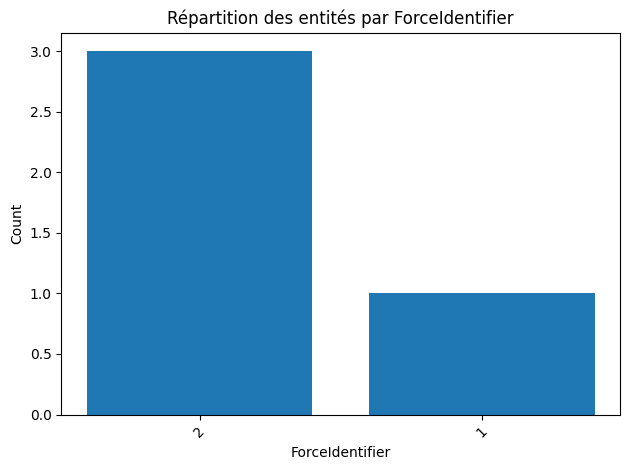


Graph saved to: out8.png


In [45]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des entités par ForceIdentifier",
    out="out8.png"
)



INTENTION DETECTE:
 {'intent': 'distribution', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}

DEBUG INTENTION: {'intent': 'distribution', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage'}]}


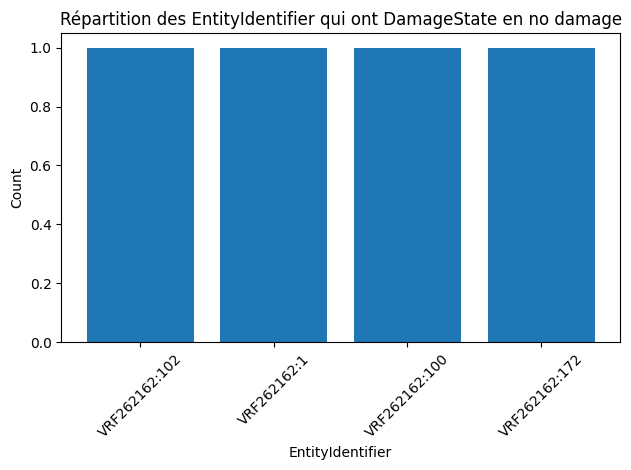


Graph sauvegardé dans: out8.png


In [ ]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des EntityIdentifier qui ont DamageState en no damage",
    out="out8.png"
)



INTENT DETECTED:
 {'intent': 'count', 'filter': [{'column': 'Immobilized'}, {'column': 'ForceIdentifier'}]}

DEBUG INTENT: {'intent': 'count', 'filter': [{'column': 'Immobilized'}, {'column': 'ForceIdentifier'}]}
[warn] Filters produced empty df, fallback to unfiltered df.


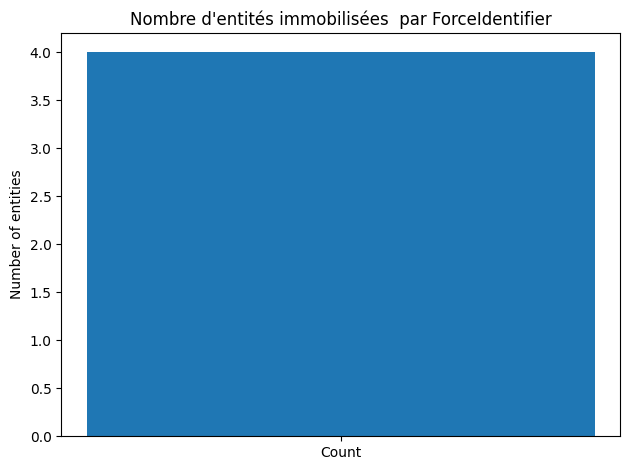


Graph saved to: out8.png


In [48]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Nombre d'entités immobilisées  par ForceIdentifier",
    out="out8.png"
)



INTENTION DETECTE:
 {'intent': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y'}

DEBUG INTENTION: {'intent': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y'}


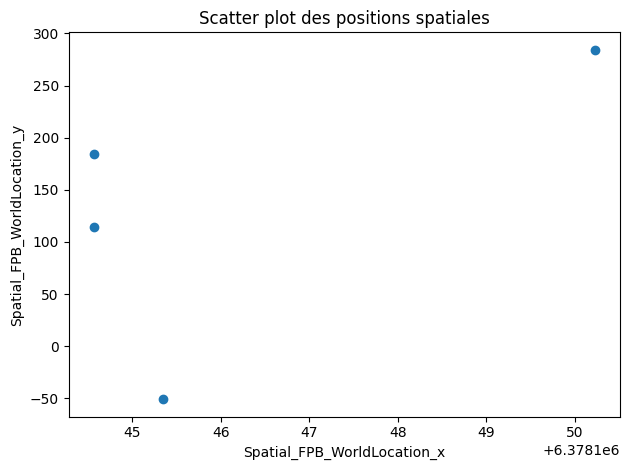


Graph sauvegardé dans: out8.png


In [63]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Scatter plot des positions spatiales",
    out="out8.png"
)






INTENTION DETECTE:
 {'intent': 'count', 'group_by': 'HlaObjectType', 'filter': [{'column': 'IsConcealed', 'value': False}]}

DEBUG INTENTION: {'intent': 'count', 'group_by': 'HlaObjectType', 'filter': [{'column': 'IsConcealed', 'value': False}]}


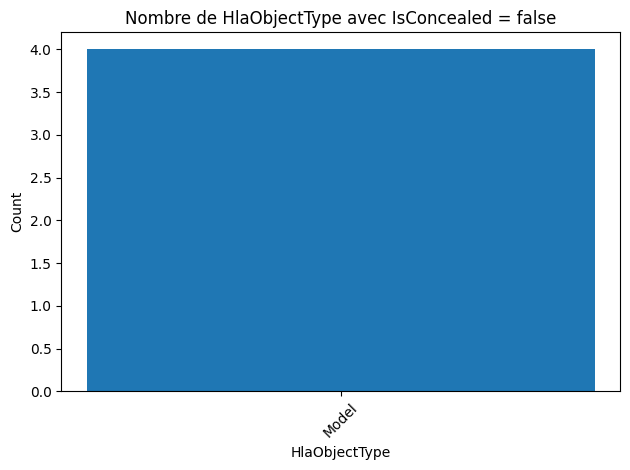


Graph sauvegardé dans: out8.png


In [11]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Nombre de HlaObjectType avec IsConcealed = false",
    out="out8.png"
)




INTENTION DETECTE:
 {'intent': 'line', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x', 'filter': [{'column': 'EntityType', 'value': 'your_entity_type'}]}

DEBUG INTENTION: {'intent': 'line', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x', 'filter': [{'column': 'EntityType', 'value': 'your_entity_type'}]}
[filter] ignore: la valeur 'your_entity_type' n'est pas dans les valeurs uniques de EntityType


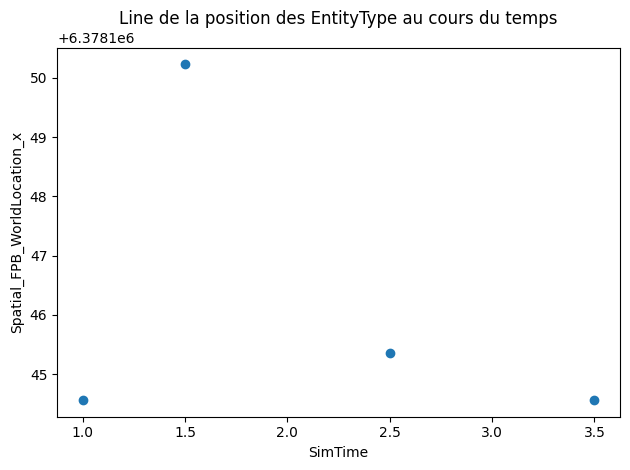


Graph sauvegardé dans: out10.png


In [20]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Line de la position des EntityType au cours du temps",
    out="out10.png"
)

# Ne marche pas car le cas passe par celui du scatter avant le line, il faut durcir le cas du scatter ou inverser l'ordre (éviter le second)